# 04 — นำเข้าข้อมูล IoT จาก ThingsBoard (L2 Data twin)

**เป้าหมาย**: ดึง telemetry ทั้งหมดที่ ThingsBoard (cat-smartgrow.com) เก็บไว้ของอุปกรณ์ 4 ตัวในห้อง → เก็บสำเนาในเครื่อง → ทำความสะอาด → ตารางเวลา 10 นาที พร้อมใช้กับ twin

ไฟล์ที่ได้
- `data/raw/iot/thingsboard_long.parquet` — ข้อมูลดิบทุกตัวอย่าง (`ts, device, key, value`) เพิ่มแบบ incremental ทุกครั้งที่รัน
- `data/processed/iot_10min.parquet` — wide 10 นาที ผ่าน QC แล้ว (คอลัมน์ `device.key`)
- `data/processed/iot_qc_report.csv` — จำนวนค่าที่ถูกตัดต่อคอลัมน์

โค้ดดึงข้อมูลอยู่ใน `pfal_twin/thingsboard.py` (public token ของ dashboard — ถ้าถูกปิดให้ใช้ `Client.login_user`) และถ้าออฟไลน์ notebook จะ fallback ไปใช้ CSV ตัวอย่าง 7 วัน

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


## 1. เชื่อมต่อและสำรวจ: อุปกรณ์, key, ข้อมูลเก่าสุดที่มี

In [2]:
try:
    client = tb.Client().login_public()
    ONLINE = True
except Exception as e:
    print("ThingsBoard unreachable ->", type(e).__name__, "| falling back to sample CSV"); ONLINE = False
if ONLINE:
    probe = dict(gw="xy_md_20_t", gc1="ec", gc2="ec", co2="CO2")
    rows = []
    for a, d in tb.DEVICES.items():
        ks = client.keys(d["id"])
        rows.append(dict(alias=a, device=d["name"], role=d["role"], n_keys=len(ks), stored_keys=len(tb.KEYS[a] or ks),
                         earliest=client.earliest_ts(d["id"], probe[a])))
    display(pd.DataFrame(rows).set_index("alias"))

,device,role,n_keys,stored_keys,earliest
alias,,,,,
gw,DOAIoTGateway,IoT gateway: 5x XY-MD02 T/RH (Modbus addr 20-2...,11,11,2026-06-24 10:51:16.588000+07:00
gc1,GrowControllerPlus_30c922faf128,Grow Controller at the rack END - GROWING-STAG...,48,22,2026-01-06 08:23:09.527000+07:00
gc2,GrowControllerPlus_30c922fa7390,Grow Controller at the rack SIDE - NURSERY-2 d...,66,23,2026-01-05 17:31:47.057000+07:00
co2,co2AndEnvironmentMeter_30c922faf2ec,CO2 & environment controller,8,7,2025-12-26 11:27:32.867000+07:00


## 2. ดาวน์โหลด (backfill ครั้งแรก ~1–2 นาที, ครั้งถัดไปดึงเฉพาะส่วนที่ใหม่กว่าไฟล์เดิม)
ดึงแบบ `agg=NONE` ทีละ 7 วัน เพื่อได้ทุกตัวอย่างจริง (ไม่ใช่ค่าเฉลี่ยจาก server) — เก็บ key ที่มีความหมายเท่านั้น (ข้าม firmware/calibration)

In [3]:
if ONLINE:
    long = tb.update_store(client, backfill_from="2025-12-20")
else:
    long = tb.sample_csv_to_long()
print(f"{len(long):,} samples | {long['ts'].min():%Y-%m-%d} → {long['ts'].max():%Y-%m-%d %H:%M}")
summ = (long.groupby(["device", "key"])
            .agg(n=("value", "size"), first=("ts", "min"), last=("ts", "max"), median=("value", "median"), min=("value", "min"), max=("value", "max"))
            .round(2))
summ["typical_interval_min"] = long.sort_values("ts").groupby(["device", "key"])["ts"].apply(lambda t: t.diff().median().total_seconds() / 60).round(1)
summ

gw   DOAIoTGateway                                  69 samples, 11 keys


gc1  GrowControllerPlus_30c922faf128             1,156 samples, 22 keys


gc2  GrowControllerPlus_30c922fa7390               985 samples, 23 keys


co2  co2AndEnvironmentMeter_30c922faf2ec           205 samples, 7 keys


1,239,109 samples | 2025-12-26 → 2026-09-14 18:35


n                            first  \
device key                                                  
co2    CO2         24448 2025-12-26 11:27:32.867000+07:00   
       Relay_co2    1560 2025-12-26 11:27:21.858000+07:00   
       VOC          1639 2025-12-26 11:27:33.140000+07:00   
       VPD         35854 2025-12-26 11:27:33.140000+07:00   
       humidity    35042 2025-12-26 11:27:33.140000+07:00   
...                  ...                              ...   
gw     xy_md_22_t   6462 2026-06-24 10:51:19.986000+07:00   
       xy_md_23_h   6452 2026-06-24 10:51:22.191000+07:00   
       xy_md_23_t   6452 2026-06-24 10:51:22.191000+07:00   
       xy_md_24_h   6465 2026-06-24 10:51:24.092000+07:00   
       xy_md_24_t   6465 2026-06-24 10:51:24.092000+07:00   

                                              last  median   min  \
device key                                                         
co2    CO2        2026-09-14 18:35:25.699000+07:00  991.00   0.0   
       Relay_co2  2026-09-14 15:18:36.317000+07:00    1.00   0.0   
       VOC        2026-09-14 18:35:25.734000+07:00    1.00   0.0   
       VPD        2026-09-14 18:35:25.769000+07:00    1.19   0.0   
       humidity   2026-09-14 18:35:25.735000+07:00   66.89  -6.0   
...                                            ...     ...   ...   
gw     xy_md_22_t 2026-09-14 09:14:53.453000+07:00   24.30  20.4   
       xy_md_23_h 2026-09-14 09:14:55.356000+07:00   64.30  39.3   
       xy_md_23_t 2026-09-14 09:14:55.356000+07:00   24.50  20.7   
       xy_md_24_h 2026-09-14 09:14:57.577000+07:00   71.10  42.6   
       xy_md_24_t 2026-09-14 09:14:57.577000+07:00   30.20  25.0   

                            max  typical_interval_min  
device key                                             
co2    CO2         4.021000e+03                   1.0  
       Relay_co2   1.000000e+00                   0.8  
       VOC         2.147484e+09                  29.3  
       VPD         5.955000e+01                   1.0  
       humidity    1.000000e+02                   1.0  
...                         ...                   ...  
gw     xy_md_22_t  3.060000e+01                   5.0  
       xy_md_23_h  9.930000e+01                   5.0  
       xy_md_23_t  3.100000e+01                   5.0  
       xy_md_24_h  9.930000e+01                   5.0  
       xy_md_24_t  3.820000e+01                   5.0  

[63 rows x 7 columns]

## 3. Wide 10 นาที + QC (ช่วงค่าที่เป็นไปได้ทางกายภาพ, ตัด `waterTemperature` ที่ probe ไม่ได้ต่อ)

In [4]:
w_raw = tb.to_wide(long, freq="10min")
w, qc = tb.clean_wide(w_raw)
env, ctrl = tb.split_env_control(w)
ctrl = tb.state_ffill(ctrl)                       # ค่าสถานะ/ตั้งค่าเปลี่ยนเมื่อมี event -> hold forward
w = pd.concat([env, ctrl], axis=1)
w.to_parquet(tb.WIDE_PARQUET); qc.to_csv(io.PROCESSED / "iot_qc_report.csv")
print(f"wide table {w.shape[0]:,} rows x {w.shape[1]} columns  ({w.index.min():%Y-%m-%d} → {w.index.max():%Y-%m-%d})  saved -> {tb.WIDE_PARQUET.name}")
qc[qc.removed > 0].sort_values("removed", ascending=False)

wide table 37,772 rows x 61 columns  (2025-12-26 → 2026-09-14)  saved -> iot_10min.parquet


,n,range,removed
column,,,
co2.humidity,4794,5–100,145
co2.pressure,4849,95–106,86
gc1.ec,11741,0.1–6,56
gc2.ec,11101,0.1–6,18
co2.temperature,4924,5–50,17
co2.CO2,4979,300–5000,13
co2.VPD,4829,0–6,9
co2.VOC,1210,0–1000,7


## 4. ความครบถ้วนของข้อมูล — สัดส่วนช่วง 10 นาทีที่มีข้อมูล ต่ออุปกรณ์ต่อวัน

overall availability:
col
co2    0.15
gc1    0.31
gc2    0.29
gw     0.10


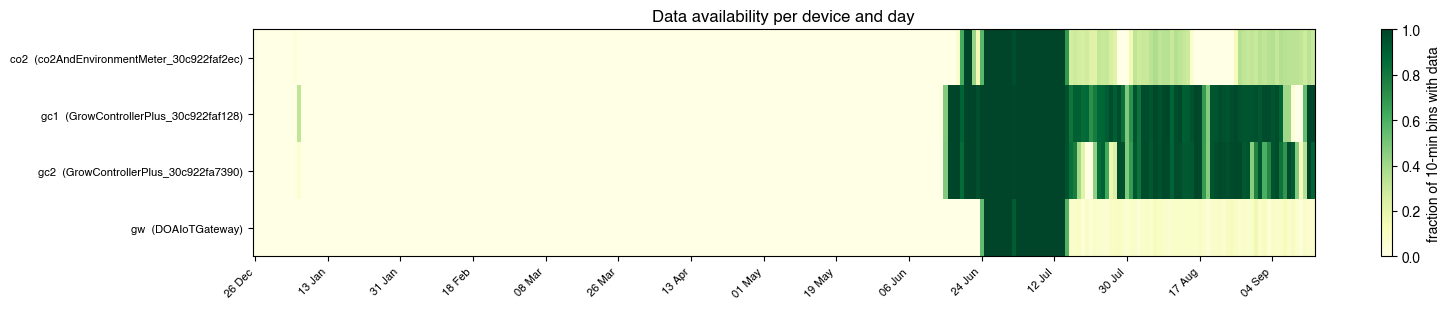

In [5]:
av = tb.availability(env, "1D")
fig, ax = plt.subplots(figsize=(16, 3.2))
im = ax.imshow(av.T.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(av.shape[1])); ax.set_yticklabels([f"{a}  ({tb.DEVICES[a]['name']})" for a in av.columns], fontsize=8)
step = max(1, len(av) // 14); ax.set_xticks(range(0, len(av), step)); ax.set_xticklabels([d.strftime("%d %b") for d in av.index[::step]], rotation=45, ha="right", fontsize=8)
plt.colorbar(im, ax=ax, label="fraction of 10-min bins with data"); ax.set_title("Data availability per device and day")
fig.tight_layout(); fig.savefig(FIG / "04_availability.png", dpi=150)
print("overall availability:"); print(av.mean().round(2).to_string())

## 5. อุณหภูมิ/ความชื้นจาก XY-MD02 5 จุด — ห้องปลูก 3 จุดบนผนัง (21–23), ห้องหน้า (20), นอกห้อง (24); mapping จาก label บน dashboard

,location,zone,mean °C,p95 °C,max °C,hours > 30 °C,day-night swing °C,mean RH %,mean VPD kPa,n bins
channel,,,,,,,,,,
xy_md_21,"Grower room 1 (wall, X 1.25 m)",room,24.17,25.20,30.6,0.33,1.57,67.19,0.99,3451
xy_md_22,"Grower room 2 (wall, X 3.6 m)",room,24.26,25.20,30.6,0.33,1.13,67.67,0.98,3443
xy_md_23,"Grower room 3 (wall, X 5.65 m)",room,24.41,25.25,31.0,0.33,0.96,66.50,1.02,3432
xy_md_20,Inside = anteroom (above the door),anteroom,27.33,30.30,32.7,53.83,3.59,65.66,1.27,3441
xy_md_24,Outside (on the CO2 box),outside,30.69,35.85,38.0,297.50,6.92,71.47,1.37,3445


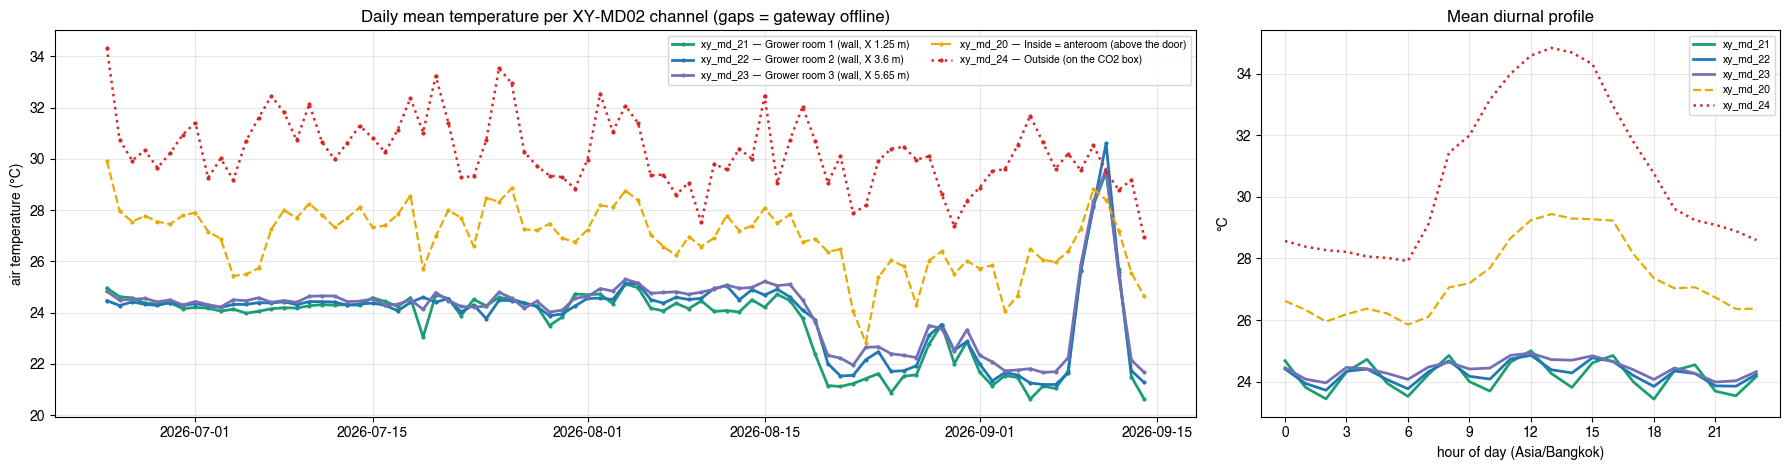

In [6]:
T = tb.channel_frame(w, "t"); H = tb.channel_frame(w, "h")
STYLE = {"room": ("-", 2.0), "anteroom": ("--", 1.6), "outside": (":", 1.8)}
cols = {"xy_md_21": "#1b9e77", "xy_md_22": "#1f78b4", "xy_md_23": "#7570b3", "xy_md_20": "#e6ab02", "xy_md_24": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(18, 4.8), gridspec_kw=dict(width_ratios=[2.2, 1]))
Td = T.resample("1D").mean(); prof = T.groupby(T.index.hour).mean()
for c in T.columns:
    ls, lw = STYLE[tb.CHANNELS[c]["zone"]]
    axes[0].plot(Td.index, Td[c], ls=ls, lw=lw, marker="o", ms=2, color=cols[c], label=tb.channel_label(c))
    axes[1].plot(prof.index, prof[c], ls=ls, lw=lw, color=cols[c], label=c)
axes[0].set_ylabel("air temperature (°C)"); axes[0].set_title("Daily mean temperature per XY-MD02 channel (gaps = gateway offline)"); axes[0].legend(fontsize=7.5, ncol=2); axes[0].grid(alpha=.3)
axes[1].set_xlabel("hour of day (Asia/Bangkok)"); axes[1].set_ylabel("°C"); axes[1].set_title("Mean diurnal profile"); axes[1].grid(alpha=.3); axes[1].set_xticks(range(0, 24, 3)); axes[1].legend(fontsize=7.5)
fig.tight_layout(); fig.savefig(FIG / "04_channel_temperature.png", dpi=150)
stats = pd.DataFrame({"location": [tb.CHANNELS[c]["short"] for c in T.columns], "zone": [tb.CHANNELS[c]["zone"] for c in T.columns],
                      "mean °C": T.mean().values, "p95 °C": T.quantile(.95).values, "max °C": T.max().values, "hours > 30 °C": ((T > 30).sum() / 6).values,
                      "day-night swing °C": (prof.max() - prof.min()).values, "mean RH %": H.mean().values, "mean VPD kPa": tb.vpd_kpa(T, H).mean().values,
                      "n bins": T.count().values}, index=T.columns).round(2)
stats.index.name = "channel"; stats

**ห้องปลูก** (21–23, ผนังฝั่งแอร์ที่ 1.3–1.4 ม.) อยู่ที่ ~24 °C ทั้ง 3 จุด แกว่งวันละ ~1–1.6 °C → ห้องควบคุมอุณหภูมิได้สม่ำเสมอตามความยาว
**ห้องหน้า** (20) ~27 °C และ **นอกห้อง** (24) ~31 °C แกว่ง 7 °C/วัน พีค 13:00 — ค่า "ร้อน" ที่เคยตีความเป็น hot spot ชั้นบนคืออากาศนอกห้อง
(ลำดับ Grower Room 1/2/3 ↔ W1/W2/W3 ตามระยะจากประตูเป็นการเดา — ทั้ง 3 ค่าใกล้กันมากจึงไม่กระทบผล)

## 6. CO₂ / VPD และวงจรปุ๋ย (EC, pH เทียบ setpoint)

,count,mean,std,min,25%,50%,75%,max
col,,,,,,,,
gc1.ph,11741.0,5.73,0.72,3.03,5.48,5.56,5.98,9.78
gc1.pHSetPoint,13279.0,5.70,0.17,5.60,5.60,5.60,5.80,6.00
gc2.ph,11101.0,6.02,1.18,3.18,5.40,5.76,6.76,9.47
gc2.pHSetPoint,11221.0,5.74,0.16,5.60,5.60,5.60,5.80,6.00


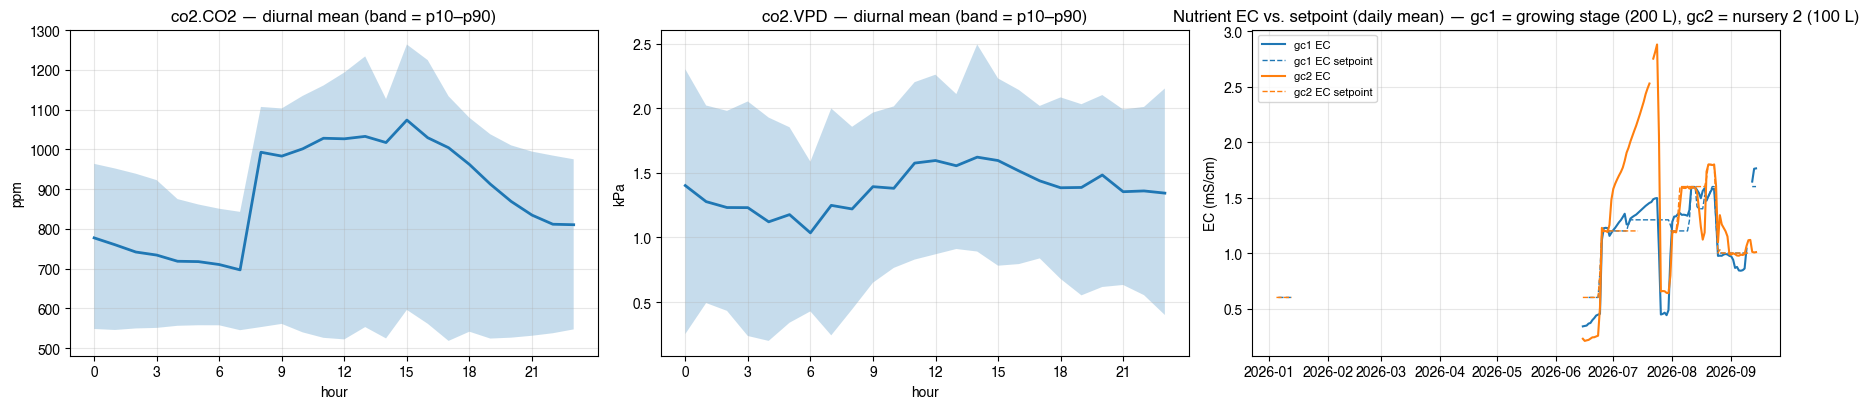

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
c = w.filter(like="co2.")
for k, ax, unit in zip(["co2.CO2", "co2.VPD"], axes[:2], ["ppm", "kPa"]):
    if k in c:
        g = c[k].groupby(c.index.hour); m_, lo, hi = g.mean(), g.quantile(.1), g.quantile(.9)
        ax.fill_between(m_.index, lo, hi, alpha=.25); ax.plot(m_.index, m_, lw=2)
        ax.set_title(f"{k} — diurnal mean (band = p10–p90)"); ax.set_xlabel("hour"); ax.set_ylabel(unit); ax.grid(alpha=.3); ax.set_xticks(range(0, 24, 3))
ax = axes[2]
for a, col in (("gc1", "#1f77b4"), ("gc2", "#ff7f0e")):
    if f"{a}.ec" in w:
        e = w[f"{a}.ec"].resample("1D").mean(); ax.plot(e.index, e, color=col, lw=1.5, label=f"{a} EC")
        if f"{a}.ecSetPoint" in w: ax.plot(e.index, w[f"{a}.ecSetPoint"].resample("1D").mean(), color=col, ls="--", lw=1, label=f"{a} EC setpoint")
ax.set_ylabel("EC (mS/cm)"); ax.set_title("Nutrient EC vs. setpoint (daily mean) — gc1 = growing stage (200 L), gc2 = nursery 2 (100 L)"); ax.legend(fontsize=8); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIG / "04_co2_vpd_ec.png", dpi=150)
ph = w[[k for k in ("gc1.ph", "gc1.pHSetPoint", "gc2.ph", "gc2.pHSetPoint") if k in w]].describe().T.round(2); ph

## สรุปจาก Notebook 04
- ข้อมูลย้อนหลังดึงได้ตั้งแต่ปลาย ธ.ค. 2025 (CO₂), ม.ค. 2026 (Grow Controller) และ มิ.ย. 2026 (Gateway T/RH 5 จุด: ห้องปลูก 3 จุดบนผนัง, ห้องหน้า, นอกห้อง) — เก็บสำเนาไว้แล้วใน Parquet รันซ้ำเพื่ออัปเดต
- ค่าที่ใช้ไม่ได้: `waterTemperature` (ทั้งคอลัมน์), `ambTemperature/ambHumidity` ของ Grow Controller = อุณหภูมิในกล่อง (ยังเก็บไว้แต่ไม่ใช้เป็นอากาศห้อง), outlier ของ CO₂ controller ถูกตัดตาม `QC_RANGES`
- Gateway offline เป็นช่วง → dashboard ต้องแสดง "no data" ไม่ interpolate ข้าม
- ตัวแปรควบคุม (led, brightness, ปั๊ม, setpoint, plantDay) ถูก forward-fill เป็น state ต่อเนื่อง → เป็น input ของโมเดล L3

**ถัดไป — Notebook 05**: แสดงข้อมูลนี้บนโมเดล 3 มิติ + time slider + KPI